# AXIOMchat - Conversational Context Pruning
### Modelling LLM Chat History as a DAG for Semantic Relevance Scoring

**Problem:** Enterprise LLM sessions accumulate stale context — dead reasoning chains, 
superseded tool outputs, off-topic exchanges. Sending bloated history on every API call 
increases cost and degrades response quality.

**Approach:** Model conversation history as a Directed Acyclic Graph (DAG), score edges 
and nodes for semantic relevance using sentence embeddings, and prune nodes that are 
structurally safe and semantically redundant.

---
**Stack:** `networkx` · `sentence-transformers` · `scikit-learn` · `numpy` · `pandas` · `matplotlib`


## 1. Setup & Imports

In [38]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
import json, textwrap

from src.embedder import MockEmbedder, SemanticScorer, score_report
from src.datahub import Datahub          
from src.graph_engine import ChatGraphEngine

embedder = MockEmbedder(dim=384)
scorer   = SemanticScorer(embedder)
datahub  = Datahub("../data/datahub.json")   

print("Setup complete.")


Setup complete.


## 2. The Problem — What is Context Pollution?

In enterprise API usage, LLM sessions accumulate irrelevant context over time:

| Pollution Type | Example |
|---|---|
| Social filler | "Hi", "Thanks", "Got it" |
| Stale reasoning | Early failed attempts before the fix was found |
| Off-topic tangents | Hardware question in a pure software session |
| Dead tool outputs | Large JSON blobs used once, now just bloating context |

**Key insight:** relevance is not a property of a single node — it depends on what 
came after it. A question about GPUs looks like a tangent until the final solution uses CUDA.


## 3. Graph Model — Conversation as a DAG

In [39]:
messages = [
    {"id": "m1", "parent_id": None,  "role": "user",      "text": "Hi there!"},
    {"id": "m2", "parent_id": "m1",  "role": "user",      "text": "How do I allocate memory on a CUDA device?"},
    {"id": "m3", "parent_id": "m2",  "role": "assistant", "text": "Use cudaMalloc to allocate device memory. It works similarly to malloc but on the GPU."},
    {"id": "m4", "parent_id": "m2",  "role": "user",      "text": "Can I use thrust with CUDA kernels?"},
    {"id": "m5", "parent_id": "m4",  "role": "assistant", "text": "Yes, thrust works alongside CUDA kernels. You can use thrust device vectors and then pass raw pointers to your kernels."},
    {"id": "m6", "parent_id": "m1",  "role": "user",      "text": "Thanks, got it!"},
    {"id": "m7", "parent_id": None,  "role": "user",      "text": "I want to learn something today"},
    {"id": "m8", "parent_id": "m3",  "role": "user",      "text": "What about cudaFree? When should I call it?"},
    {"id": "m9", "parent_id": "m3",  "role": "user",      "text": "Does this work on TPUs too?"},
]

engine = ChatGraphEngine(datahub, scorer=None, threshold=0.25)
for m in messages:
    engine.add_message(m["id"], m["parent_id"], m["text"])

print(f"Nodes: {list(engine.G.nodes)}")
print(f"Edges: {list(engine.G.edges)}")


Nodes: ['m1', 'm2', 'm3', 'm4', 'm5', 'm6', 'm7', 'm8', 'm9']
Edges: [('m1', 'm2'), ('m1', 'm6'), ('m2', 'm3'), ('m2', 'm4'), ('m3', 'm8'), ('m3', 'm9'), ('m4', 'm5')]


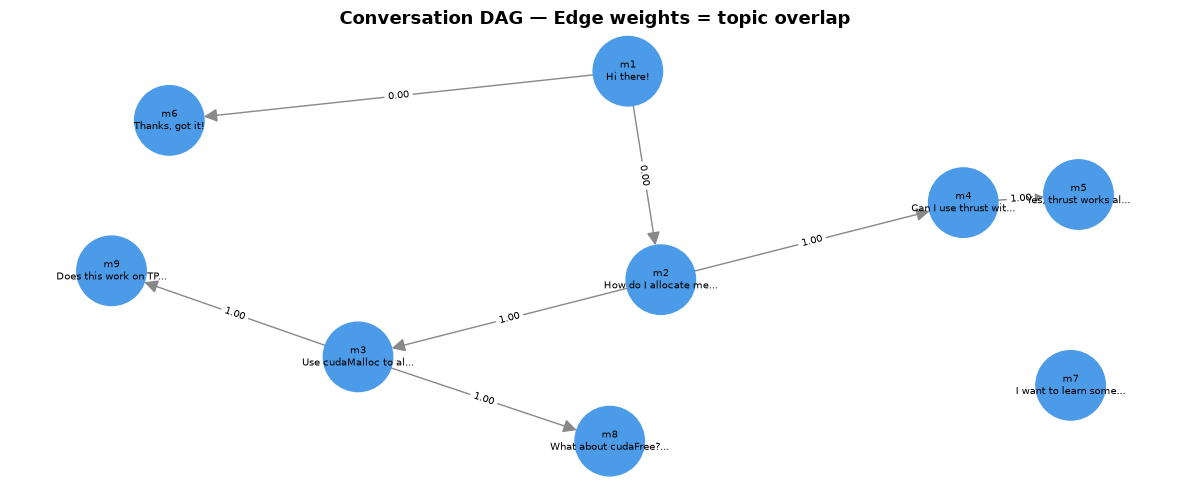

In [40]:
# Visualise the DAG
def draw_graph(G, title="Conversation DAG", node_colors=None):
    fig, ax = plt.subplots(figsize=(12, 5))
    pos = nx.spring_layout(G, seed=42)

    colors  = node_colors or ["#4C9BE8"] * len(G.nodes)
    labels  = {n: f"{n}\n{G.nodes[n]['text'][:20]}..." 
               if len(G.nodes[n]['text']) > 20 
               else f"{n}\n{G.nodes[n]['text']}" 
               for n in G.nodes}
    
    edge_labels = {(u,v): f"{d['weight']:.2f}" for u,v,d in G.edges(data=True)}
    
    nx.draw(G, pos, labels=labels, node_color=colors, node_size=2500,
            font_size=7, arrows=True, arrowsize=20,
            edge_color="#888", ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)
    
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

draw_graph(engine.G, "Conversation DAG — Edge weights = topic overlap")


## 4. The Datahub — Topic Taxonomy

The datahub is a curated knowledge base of topics with keyword signatures.
Edge weights between nodes are computed as **Jaccard similarity of matched topics**.

This is the **lexical RAG** layer — v2 replaces keyword matching with embedding retrieval.


In [41]:
with open("../data/datahub.json") as f:
    hub = json.load(f)

# Show topic coverage
rows = []
for topic, entry in hub["topics"].items():
    rows.append({"topic": topic, "keywords": len(entry["keywords"]),
                 "sample": ", ".join(entry["keywords"][:5])})

df_topics = pd.DataFrame(rows)
print(df_topics.to_string(index=False))
print(f"\nGlobal noise patterns: {len(hub['global_noise'])}")


             topic  keywords                                                 sample
parallel_computing        18                         gpu, cuda, thrust, cub, kernel
 systems_debugging        14 segfault, stacktrace, traceback, exception, breakpoint
       web_network        19               http, https, request, response, endpoint
       ml_training        17             loss, epoch, gradient, optimizer, backprop
  data_engineering        18                pipeline, etl, dataframe, schema, query

Global noise patterns: 25


## 5. Embedding Layer — Semantic Scoring

Each node is embedded using `sentence-transformers/all-MiniLM-L6-v2` (384-dim).
Relevance is computed as **cosine similarity** between each node and the **session anchor**.

**Session anchor** = mean embedding of all non-noise nodes — the semantic center of mass
of the conversation, robust to greetings and filler at the start/end.

> On this machine: MockEmbedder (hash-seeded random vectors, uniform scores expected)  
> On your machine: swap to `Embedder()` for real semantic differentiation


In [42]:
df = score_report(messages, scorer, datahub_path="../data/datahub.json", threshold=0.25)
print(df.to_string(index=False))


id      role                                                         text  is_noise  relevance  edge_weight  deletable
m1      user                                                    Hi there!      True      0.854          NaN       True
m2      user                   How do I allocate memory on a CUDA device?     False      0.866        0.765      False
m3 assistant Use cudaMalloc to allocate device memory. It works similarly     False      0.882        0.729      False
m4      user                          Can I use thrust with CUDA kernels?     False      0.886        0.750      False
m5 assistant Yes, thrust works alongside CUDA kernels. You can use thrust     False      0.879        0.742      False
m6      user                                              Thanks, got it!     False      0.887        0.742      False
m7      user                              I want to learn something today     False      0.882          NaN      False
m8      user                  What about cudaFre

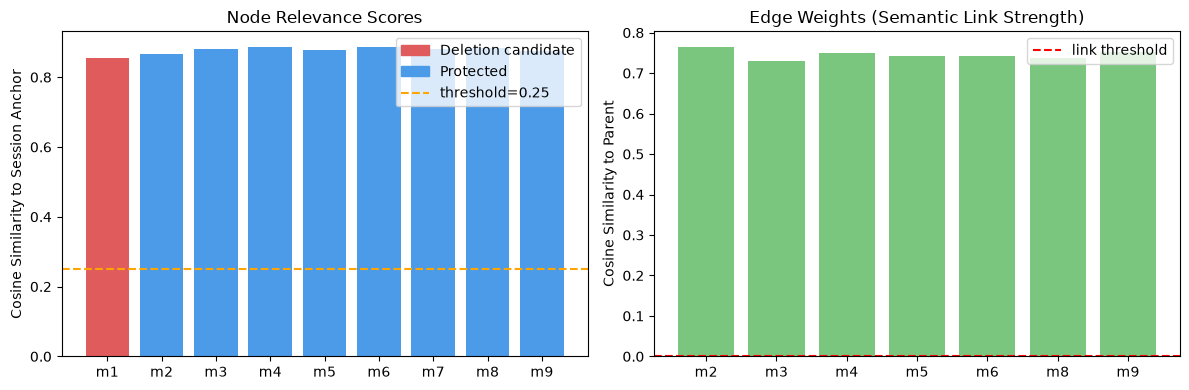

In [43]:
# Visualise score distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Relevance scores
colors = ["#E05C5C" if d else "#4C9BE8" for d in df["deletable"]]
ax1.bar(df["id"], df["relevance"], color=colors)
ax1.axhline(0.25, color="orange", linestyle="--", label="threshold=0.25")
ax1.set_title("Node Relevance Scores")
ax1.set_ylabel("Cosine Similarity to Session Anchor")
ax1.legend()

# Edge weights
ew = df.dropna(subset=["edge_weight"])
ax2.bar(ew["id"], ew["edge_weight"], color="#7BC67E")
ax2.axhline(0.0, color="red", linestyle="--", label="link threshold")
ax2.set_title("Edge Weights (Semantic Link Strength)")
ax2.set_ylabel("Cosine Similarity to Parent")
ax2.legend()

red_patch   = mpatches.Patch(color="#E05C5C", label="Deletion candidate")
blue_patch  = mpatches.Patch(color="#4C9BE8", label="Protected")
ax1.legend(handles=[red_patch, blue_patch,
           plt.Line2D([0],[0], color="orange", linestyle="--", label="threshold=0.25")])

plt.tight_layout()
plt.show()


## 6. Bottom-Up Score Propagation

**The key insight:** a node's deletability depends on its descendants, not just itself.

A question about GPUs scores low in isolation — but if its child is a highly relevant 
CUDA implementation, the parent must be protected.

**Propagation rules:**
- **Leaf nodes** → own score only
- **Linear chain nodes** (out-degree=1) → `max(own_score, child_final_score)`
- **Branching nodes** (out-degree≥2) → own score only (children are independent threads)

**Structural gate:** a node is only blocked by children connected via `edge_weight > 0`.
Zero-weight edges = no semantic dependency = parent can be deleted independently.


In [44]:
engine.score_session()
engine.summary()


  Session anchor: "How do I allocate memory on a CUDA device? | Use cudaMalloc to allocate device m..."

── Graph summary ───────────────────────────────────
Nodes     : ['m1', 'm2', 'm3', 'm4', 'm5', 'm6', 'm7', 'm8', 'm9']
Edges     : [('m1', 'm2', 0.0), ('m1', 'm6', 0.0), ('m2', 'm3', 1.0), ('m2', 'm4', 1.0), ('m3', 'm8', 1.0), ('m3', 'm9', 1.0), ('m4', 'm5', 1.0)]
Isolated  : ['m7']
Threads   : [['m1', 'm2', 'm3', 'm4', 'm5', 'm6', 'm8', 'm9']]
  m1: "Hi there!" | final_score=0.00
  m2: "How do I allocate memory on a CUDA devic" | final_score=0.30
  m3: "Use cudaMalloc to allocate device memory" | final_score=0.30
  m4: "Can I use thrust with CUDA kernels?" | final_score=0.30
  m5: "Yes, thrust works alongside CUDA kernels" | final_score=0.30
  m6: "Thanks, got it!" | final_score=0.00
  m7: "I want to learn something today" | final_score=0.00
  m8: "What about cudaFree? When should I call " | final_score=0.30
  m9: "Does this work on TPUs too?" | final_score=0.30
Deletable : ['m1',

In [45]:
# Show propagated vs raw scores
rows = []
for n in engine.G.nodes:
    rows.append({
        "id": n,
        "text": engine.G.nodes[n]["text"][:45],
        "raw_score":   round(engine.G.nodes[n].get("score", 0), 3),
        "final_score": round(engine.G.nodes[n].get("final_score", 0), 3),
        "out_degree":  engine.G.out_degree(n),
        "deletable":   engine.can_delete(n)[0]
    })

df_prop = pd.DataFrame(rows)
print(df_prop.to_string(index=False))


id                                          text  raw_score  final_score  out_degree  deletable
m1                                     Hi there!        0.0          0.0           2       True
m2    How do I allocate memory on a CUDA device?        0.3          0.3           2      False
m3 Use cudaMalloc to allocate device memory. It         0.3          0.3           2      False
m4           Can I use thrust with CUDA kernels?        0.3          0.3           1      False
m5 Yes, thrust works alongside CUDA kernels. You        0.3          0.3           0      False
m6                               Thanks, got it!        0.0          0.0           0       True
m7               I want to learn something today        0.0          0.0           0       True
m8   What about cudaFree? When should I call it?        0.3          0.3           0      False
m9                   Does this work on TPUs too?        0.3          0.3           0      False


## 7. Deletion Pass

Final deletion combines two gates:
1. **Structural gate:** `out_degree == 0` OR all children have `edge_weight == 0`
2. **Semantic gate:** `final_score < threshold`

Both must pass. This ensures we never delete a node that is either structurally 
load-bearing or semantically relevant to the session.


In [46]:
print("── Deletion pass ──")
deleted, blocked = [], []
for n in list(engine.G.nodes):
    ok, reason = engine.can_delete(n)
    if ok:
        engine.delete_message(n)
        deleted.append(n)
    else:
        blocked.append((n, reason))

print(f"\nDeleted : {deleted}")
print(f"Blocked : {[(n, r) for n,r in blocked]}")


── Deletion pass ──
✅ DELETED 'm1' (leaf, score 0.00)
✅ DELETED 'm6' (leaf, score 0.00)
✅ DELETED 'm7' (leaf, score 0.00)

Deleted : ['m1', 'm6', 'm7']
Blocked : [('m2', "has 2 strongly linked reply(s): ['m3', 'm4']"), ('m3', "has 2 strongly linked reply(s): ['m8', 'm9']"), ('m4', "has 1 strongly linked reply(s): ['m5']"), ('m5', 'score 0.30 >= threshold 0.25'), ('m8', 'score 0.30 >= threshold 0.25'), ('m9', 'score 0.30 >= threshold 0.25')]


## 8. Open Problems & Research Directions

| Problem | Current approach | Limitation | V2 direction |
|---|---|---|---|
| Relevance scoring | Cosine sim to session anchor | Short messages embed poorly | Fine-tuned classifier |
| Edge weights | Topic keyword Jaccard | Can't handle paraphrasing | Semantic embedding similarity |
| Session anchor | Mean of non-noise embeddings | Sensitive to topic drift | Weighted by recency + role |
| Recency | Not modelled | Stale context scores same as fresh | Exponential decay factor |
| Branching scoring | Own score only | May miss cross-branch dependencies | GNN-based aggregation |

**The fundamental open question:**  
Cosine similarity measures *topical overlap*, not *causal dependency*.  
A node about GPUs and a final output mentioning GPUs will score high —  
but the model doesn't *know* the GPU question caused the GPU answer.  
Solving this requires either causal modelling or a supervised dataset of  
human-annotated conversation pruning decisions.
